# 🚀 Chuyên đề thiết kế IC: Mô phỏng RTL-Accurate cho BFSK Modulator
**Nhóm 5 - Đồ án Digital Modulation (Verilog HDL)**

Notebook này thực hiện mô phỏng **Bit-True** và **Cycle-Accurate** (chính xác đến từng chu kỳ xung clock) cho kiến trúc phần cứng của bộ điều chế BFSK sóng vuông.

Thay vì dùng hàm `np.sin()` lý thuyết, chúng ta xây dựng lại chính xác sơ đồ khối phần cứng trong báo cáo:
1. **Frequency Control Unit (FCU):** MUX chọn hệ số chia (N0, N1).
2. **Counter / Divider Unit (CDU):** Bộ đếm modulo tạo chu kỳ.
3. **Output Toggle Register (OTR):** Thanh ghi D-FF đảo trạng thái tạo sóng vuông.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from scipy.fft import fft, fftfreq

# Định dạng đồ thị chuyên nghiệp (Dark Mode chuẩn kỹ sư)
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['lines.linewidth'] = 1.5

# ==========================================
# 1. THÔNG SỐ HỆ THỐNG (Khớp 100% với Verilog)
# ==========================================
CLK_FREQ = 50_000_000  # Master Clock: 50 MHz (Có thể đổi thành 27_000_000 cho Tang Nano 9K)

F0_TARGET = 500_000    # Space Frequency: 500 kHz (Bit 0)
F1_TARGET = 1_000_000  # Mark Frequency: 1 MHz (Bit 1)

# Tính toán hệ số chia N cho Counter (Bán chu kỳ)
N0_DIV = int(CLK_FREQ / (2 * F0_TARGET))  # N0 = 50
N1_DIV = int(CLK_FREQ / (2 * F1_TARGET))  # N1 = 25

# Cấu hình dữ liệu đầu vào
BIT_RATE = 20_000     # Tốc độ truyền baud rate (100 kbps để dễ nhìn sóng)
CLKS_PER_BIT = CLK_FREQ // BIT_RATE       # Số chu kỳ clock cho mỗi bit dữ liệu

print(f"--- THÔNG SỐ PHẦN CỨNG ---")
print(f"Master Clock : {CLK_FREQ/1e6} MHz")
print(f"Hệ số N0 (Bit 0): {N0_DIV} -> Tạo ra f0 = {CLK_FREQ/(2*N0_DIV)/1000} kHz")
print(f"Hệ số N1 (Bit 1): {N1_DIV} -> Tạo ra f1 = {CLK_FREQ/(2*N1_DIV)/1000} kHz")
print(f"Số clock / bit : {CLKS_PER_BIT} clocks")

--- THÔNG SỐ PHẦN CỨNG ---
Master Clock : 50.0 MHz
Hệ số N0 (Bit 0): 50 -> Tạo ra f0 = 500.0 kHz
Hệ số N1 (Bit 1): 25 -> Tạo ra f1 = 1000.0 kHz
Số clock / bit : 2500 clocks


## 🧠 2. Trình mô phỏng vòng lặp sườn lên (Posedge Clock Simulator)
Hàm dưới đây mô phỏng khối `always @(posedge clk)` trong Verilog. Chúng ta không dùng mảng toán học, mà dùng vòng lặp `for` lặp qua từng chu kỳ một, cập nhật giá trị của `counter` và `modulated_out`.

In [ ]:
def simulate_rtl_bfsk(bit_stream, n0, n1, clks_per_bit):
    total_clocks = len(bit_stream) * clks_per_bit

    # Khởi tạo thanh ghi (Registers) y hệt Verilog
    reg_counter = 0
    reg_modulated_out = 0

    # Mảng lưu vết (Trace buffers) để vẽ đồ thị
    trace_out = np.zeros(total_clocks, dtype=np.int8)
    trace_counter = np.zeros(total_clocks, dtype=np.int32)
    trace_data_in = np.zeros(total_clocks, dtype=np.int8)

    clk_idx = 0

    for bit in bit_stream:
        # Combinational Logic: MUX chọn hệ số chia
        current_N = n1 if bit == 1 else n0

        for _ in range(clks_per_bit):
            # Lưu vết trạng thái hiện tại (đầu chu kỳ)
            trace_data_in[clk_idx] = bit
            trace_counter[clk_idx] = reg_counter
            trace_out[clk_idx] = reg_modulated_out

            # --- BEGIN: always @(posedge clk) ---
            if reg_counter >= (current_N - 1):
                reg_counter = 0                    # Reset counter
                reg_modulated_out ^= 1             # Toggle output (XOR với 1)
            else:
                reg_counter += 1                   # Increment counter
            # --- END: always @(posedge clk) ---

            clk_idx += 1

    return trace_out, trace_counter, trace_data_in

# Chuỗi bit thử nghiệm (1 0 1 1 0 0)
# Chuỗi bit thử nghiệm dài hơn
DATA_BITS = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0]

# Chạy mô phỏng
sig_out, sig_counter, sig_data = simulate_rtl_bfsk(DATA_BITS, N0_DIV, N1_DIV, CLKS_PER_BIT)
time_axis_us = np.arange(len(sig_out)) * (1 / CLK_FREQ) * 1e6 # Đổi ra micro-giây
print(f"Mô phỏng hoàn tất: {len(sig_out):,} chu kỳ clock.")

Mô phỏng hoàn tất: 50,000 chu kỳ clock.


## 📊 3. Khảo sát Miền Thời Gian (Time Domain Analysis)
Chúng ta sẽ bóc tách bên trong bộ điều chế. Đồ thị số 2 (Màu cam) là "Vũ khí bí mật" chứng minh thiết kế hoạt động: Nó cho thấy Counter đếm lên như thế nào (dạng răng cưa) và chạm ngưỡng giới hạn (N-1) ra sao trước khi reset.

/tmp/ipykernel_2822/3176601343.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


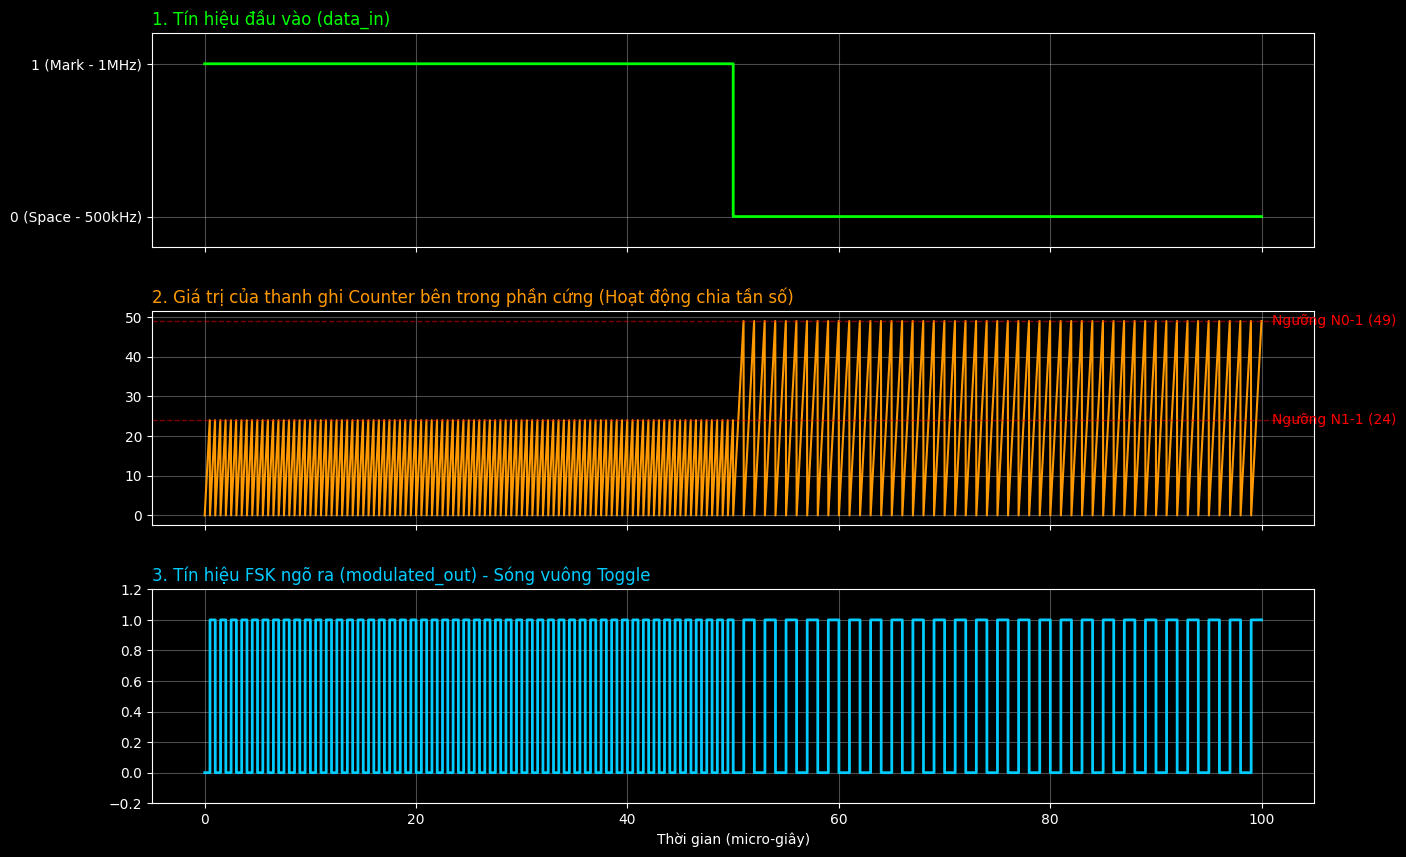

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, gridspec_kw={'hspace': 0.3})

# Giới hạn trục X để nhìn rõ sóng (Chỉ xem 2 bit đầu tiên)
ZOOM_CLOCKS = CLKS_PER_BIT * 2
t_zoom = time_axis_us[:ZOOM_CLOCKS]

# 1. Tín hiệu dữ liệu vào
axes[0].step(t_zoom, sig_data[:ZOOM_CLOCKS], where='post', color='#00FF00', lw=2)
axes[0].set_ylim(-0.2, 1.2)
axes[0].set_title('1. Tín hiệu đầu vào (data_in)', color='#00FF00', fontsize=12, loc='left')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['0 (Space - 500kHz)', '1 (Mark - 1MHz)'])

# 2. Hoạt động của Counter (Dạng răng cưa)
axes[1].plot(t_zoom, sig_counter[:ZOOM_CLOCKS], color='#FF9900', lw=1.5)
axes[1].axhline(N0_DIV-1, color='red', ls='--', lw=1, alpha=0.5)
axes[1].axhline(N1_DIV-1, color='red', ls='--', lw=1, alpha=0.5)
axes[1].text(t_zoom[-1]*1.01, N0_DIV-1, 'Ngưỡng N0-1 (49)', color='red', va='center')
axes[1].text(t_zoom[-1]*1.01, N1_DIV-1, 'Ngưỡng N1-1 (24)', color='red', va='center')
axes[1].set_title('2. Giá trị của thanh ghi Counter bên trong phần cứng (Hoạt động chia tần số)', color='#FF9900', fontsize=12, loc='left')

# 3. Sóng vuông ngõ ra
axes[2].step(t_zoom, sig_out[:ZOOM_CLOCKS], where='post', color='#00CCFF', lw=2)
axes[2].set_ylim(-0.2, 1.2)
axes[2].set_title('3. Tín hiệu FSK ngõ ra (modulated_out) - Sóng vuông Toggle', color='#00CCFF', fontsize=12, loc='left')
axes[2].set_xlabel('Thời gian (micro-giây)')

plt.tight_layout()
plt.show()

## 🎛️ 4. Phân tích Miền Tần Số (Spectrogram & Harmonics)
 Khác với sóng Sin lý thuyết chỉ có 1 vạch phổ, tín hiệu điều chế trên FPGA của chúng ta là **Sóng Vuông**. Về mặt toán học (Chuỗi Fourier), sóng vuông chứa tần số cơ bản ($f_0$ hoặc $f_1$) và **các sóng hài bậc lẻ (3f, 5f, 7f...)**.

Đồ thị Spectrogram dưới đây sẽ chứng minh chính xác điều này: Bạn sẽ thấy phổ năng lượng nhảy qua lại giữa 500kHz và 1MHz, kèm theo các bóng mờ ở băng tần cao hơn (Sóng hài bậc 3 là 1.5MHz và 3MHz).

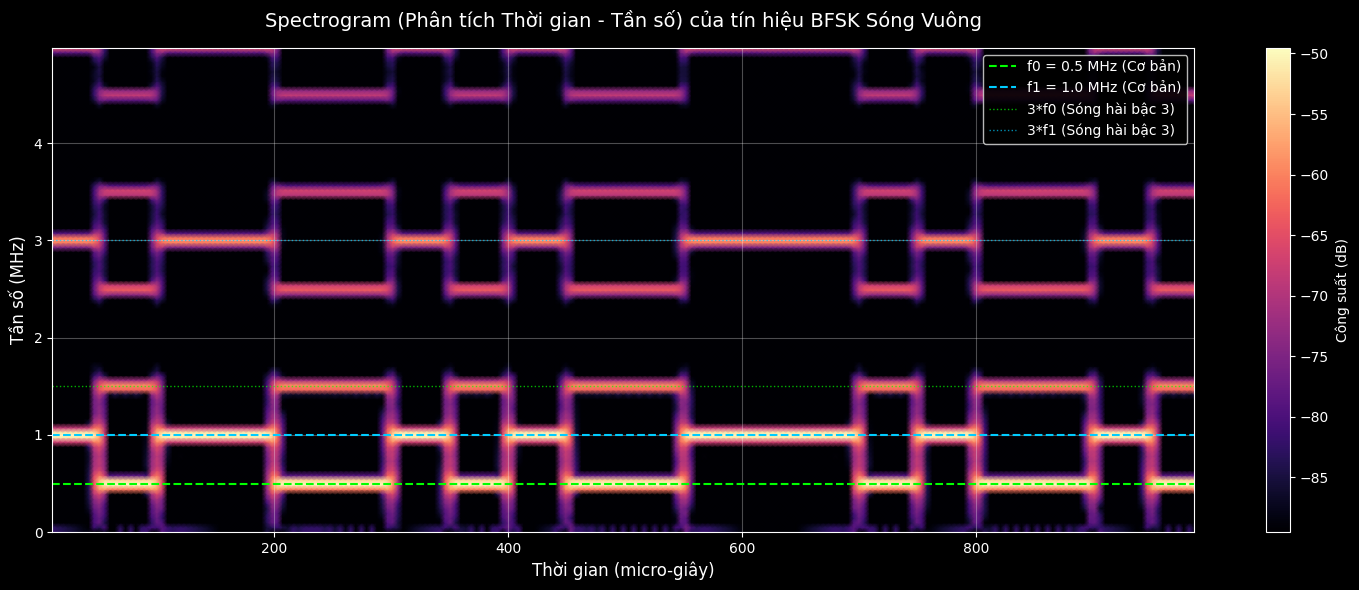

In [ ]:
# Chuyển sóng vuông từ [0, 1] thành [-1, 1] để loại bỏ thành phần DC (0Hz) khi tính FFT
sig_out_ac = sig_out * 2 - 1

# Tính toán Spectrogram với cửa sổ lớn hơn và độ trượt mượt hơn
f, t_spec, Sxx = spectrogram(sig_out_ac, fs=CLK_FREQ, window='hamming', nperseg=1024, noverlap=800)

# Chuyển đổi sang dB
Sxx_dB = 10 * np.log10(Sxx + 1e-10)

plt.figure(figsize=(15, 6))
# Chỉ vẽ băng tần từ 0 Hz đến 5 MHz để nhìn rõ các sóng hài
f_mask = f <= 5_000_000

# Ép màu sắc rực rỡ nhất bằng cách ghim vmax vào đỉnh năng lượng thực tế
pcm = plt.pcolormesh(t_spec * 1e6, f[f_mask] / 1e6, Sxx_dB[f_mask, :],
                     shading='gouraud', cmap='magma',
                     vmin=np.max(Sxx_dB) - 40, vmax=np.max(Sxx_dB))

plt.colorbar(pcm, label='Công suất (dB)')
plt.axhline(F0_TARGET/1e6, color='#00FF00', ls='--', lw=1.5, label='f0 = 0.5 MHz (Cơ bản)')
plt.axhline(F1_TARGET/1e6, color='#00CCFF', ls='--', lw=1.5, label='f1 = 1.0 MHz (Cơ bản)')

# Highlight sóng hài bậc 3
plt.axhline((F0_TARGET*3)/1e6, color='#00FF00', ls=':', lw=1, alpha=0.7, label='3*f0 (Sóng hài bậc 3)')
plt.axhline((F1_TARGET*3)/1e6, color='#00CCFF', ls=':', lw=1, alpha=0.7, label='3*f1 (Sóng hài bậc 3)')

plt.title('Spectrogram (Phân tích Thời gian - Tần số) của tín hiệu BFSK Sóng Vuông', fontsize=14, pad=15)
plt.ylabel('Tần số (MHz)', fontsize=12)
plt.xlabel('Thời gian (micro-giây)', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


Nếu bạn đưa phần này vào báo cáo hoặc lúc bảo vệ, giảng viên sẽ biết bạn THỰC SỰ hiểu thiết kế số.

**Vấn đề:**
Trong code Verilog hiện tại, nếu `data_in` chuyển từ 0 lên 1 *đúng lúc* `counter` đang đếm ở giá trị ví dụ là 30.
- Ngưỡng cũ là $N_0-1 = 49$. Counter = 30 là hoàn toàn hợp lệ.
- Ngay lập tức ngưỡng mới thành $N_1-1 = 24$.
- Mã kiểm tra `if (counter >= F1_DIV - 1)` thấy $30 > 24$, nên nó **lập tức Reset counter về 0 và đảo trạng thái ngõ ra**.
=> Điều này tạo ra một **xung bị cắt ngắn bất thường (Spurious Glitch)** tại thời điểm chuyển bit, gây nhiễu hài ở tần số cao.

**Giải pháp phần cứng:**
Chúng ta tạo thêm một thanh ghi đệm `active_N`. Giá trị của hệ số chia mới chỉ được cập nhật vào `active_N` khi `counter == 0` (tức là đã hoàn thành trọn vẹn chu kỳ nửa sóng hiện tại). Pha sẽ trượt một cách an toàn mà không bị vỡ.

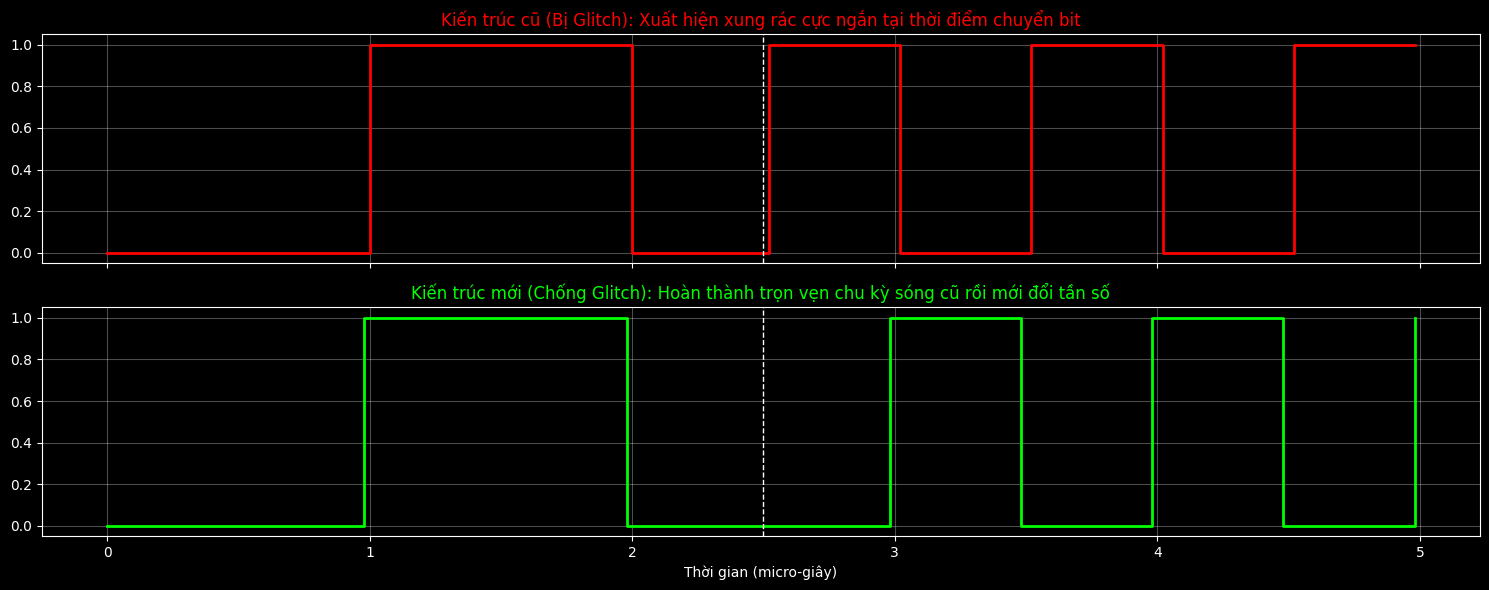

In [ ]:
def simulate_rtl_advanced_bfsk(bit_stream, n0, n1, clks_per_bit):
    """Trình mô phỏng kiến trúc chống Glitch"""
    total_clocks = len(bit_stream) * clks_per_bit

    reg_counter = 0
    reg_modulated_out = 0
    reg_active_N = n0  # Thanh ghi chốt hệ số

    trace_out = np.zeros(total_clocks, dtype=np.int8)

    clk_idx = 0
    for bit in bit_stream:
        # Combinational logic đầu vào
        target_N = n1 if bit == 1 else n0

        for _ in range(clks_per_bit):
            # --- BEGIN: Block chống Glitch ---
            # Chỉ cập nhật N mới khi bắt đầu một chu kỳ đếm mới
            if reg_counter == 0:
                reg_active_N = target_N

            if reg_counter >= (reg_active_N - 1):
                reg_counter = 0
                reg_modulated_out ^= 1
            else:
                reg_counter += 1
            # --- END ---

            trace_out[clk_idx] = reg_modulated_out
            clk_idx += 1

    return trace_out

# Cố tình tạo một điểm chuyển bit lẻ (không chia hết cho chu kỳ sóng) để ép xuất hiện Glitch
MALICIOUS_CLKS_PER_BIT = int(N0_DIV * 2.5)
sig_out_basic, _, _ = simulate_rtl_bfsk([0, 1], N0_DIV, N1_DIV, MALICIOUS_CLKS_PER_BIT)
sig_out_advanced = simulate_rtl_advanced_bfsk([0, 1], N0_DIV, N1_DIV, MALICIOUS_CLKS_PER_BIT)

time_glitch_us = np.arange(len(sig_out_basic)) * (1 / CLK_FREQ) * 1e6

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].step(time_glitch_us, sig_out_basic, where='post', color='red', lw=2)
axes[0].set_title('Kiến trúc cũ (Bị Glitch): Xuất hiện xung rác cực ngắn tại thời điểm chuyển bit', color='red')
axes[0].axvline(MALICIOUS_CLKS_PER_BIT / CLK_FREQ * 1e6, color='white', ls='--', lw=1)

axes[1].step(time_glitch_us, sig_out_advanced, where='post', color='#00FF00', lw=2)
axes[1].set_title('Kiến trúc mới (Chống Glitch): Hoàn thành trọn vẹn chu kỳ sóng cũ rồi mới đổi tần số', color='#00FF00')
axes[1].axvline(MALICIOUS_CLKS_PER_BIT / CLK_FREQ * 1e6, color='white', ls='--', lw=1)
axes[1].set_xlabel('Thời gian (micro-giây)')

plt.tight_layout()
plt.show()